Models saved:
dict_keys(['model_1', 'model_1a', 'model_1b', 'model_2', 'model_2a', 'model_2b'])


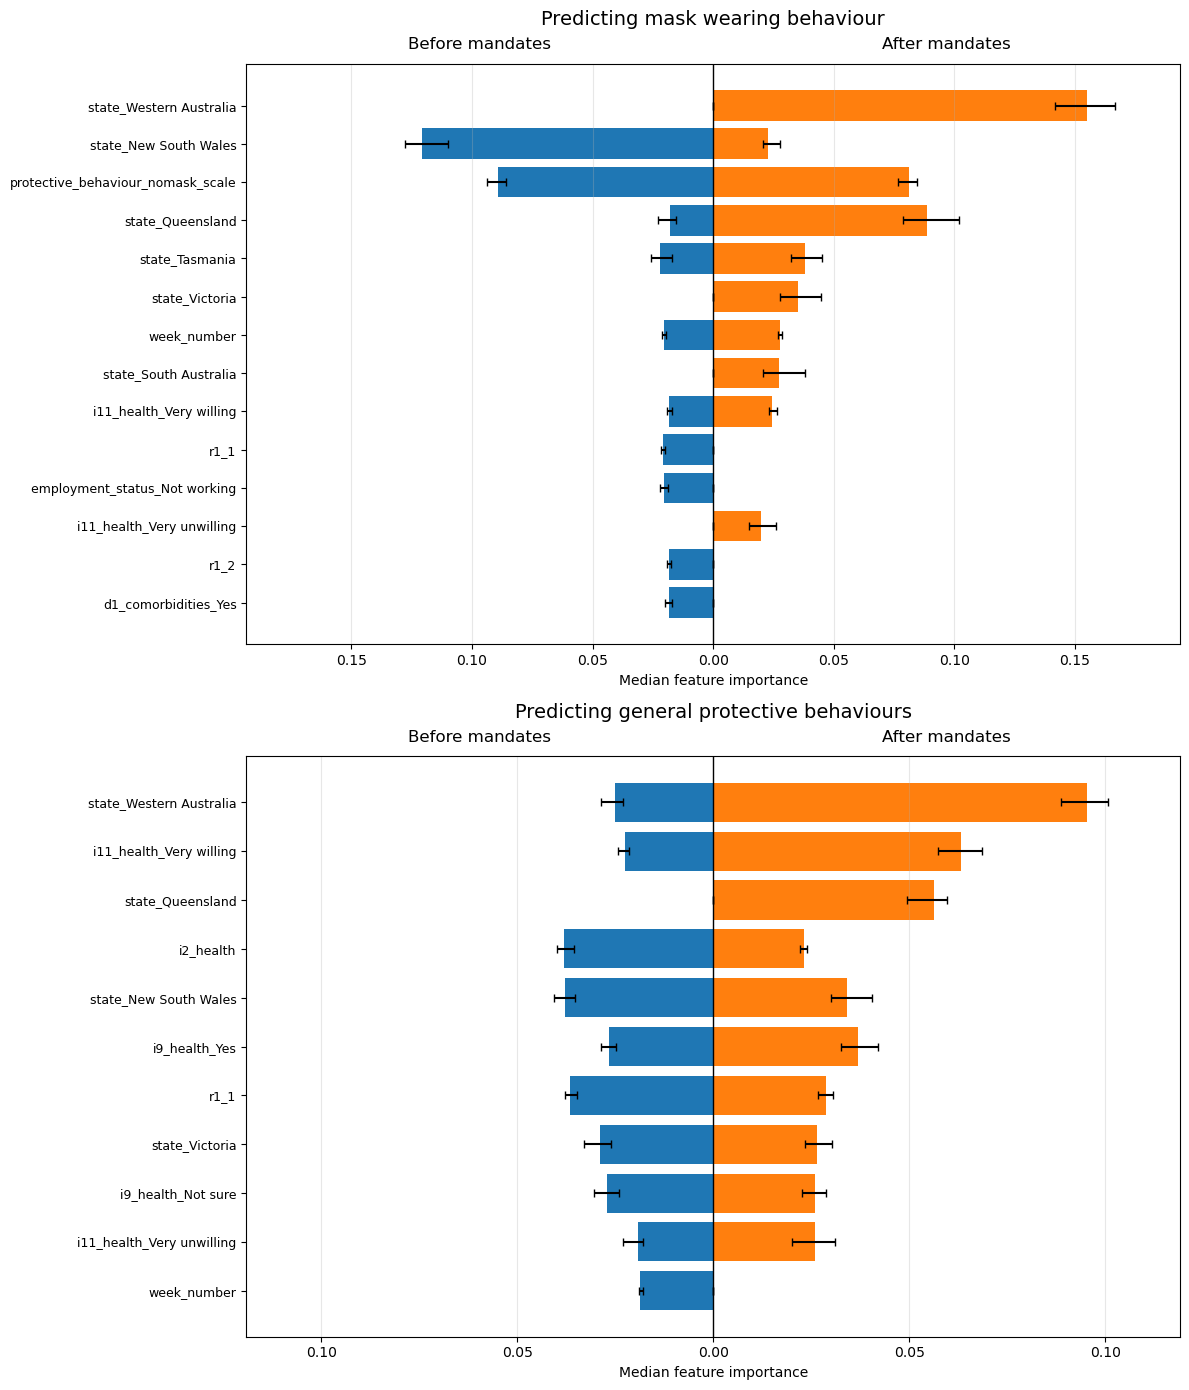

Saved to: ../feature_importance_plots/state_feature_importance_top10.png


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
from xgboost import XGBClassifier
from matplotlib.ticker import FuncFormatter

# Load saved XGBoost models
with open("../data/xgboost_final_models.pkl", "rb") as f:
    xgb_final_models = pickle.load(f)

print("Models saved:")
print(xgb_final_models.keys())

# Set output
output_dir = "../feature_importance_plots"
os.makedirs(output_dir, exist_ok=True)

model_pairs = {
    "Predicting mask wearing behaviour": ("model_1a", "model_1b"),
    "Predicting general protective behaviours": ("model_2a", "model_2b")
}

# Basic settings
top_n = 10
n_repeats = 50
seed = 42

# Load X_train and y_train
def load_model_data(model_number):
    
    X_train_path = f"../data/X_train_{model_number}.csv"
    y_train_path = f"../data/y_train_{model_number}.csv"

    if not os.path.exists(X_train_path):
        raise FileNotFoundError(f"Cannot find: {X_train_path}")
    if not os.path.exists(y_train_path):
        raise FileNotFoundError(f"Cannot find: {y_train_path}")

    X_train = pd.read_csv(X_train_path, keep_default_na=False)
    y_train = pd.read_csv(y_train_path, keep_default_na=False).values.ravel()

    return X_train, y_train

# XGBoost feature importance
def get_repeated_importance_df(model_number, n_repeats=50, seed=42):
    """
    Refit the XGBoost model multiple times.
    Calculate median importance.
    """
    if model_number not in xgb_final_models:
        raise KeyError(f"{model_number} not found in xgb_final_models")

    X_train, y_train = load_model_data(model_number)

    # Get parameters from saved model
    saved_model = xgb_final_models[model_number]
    model_params = saved_model.get_params()

    importance_records = []

    for i in range(n_repeats):
        current_seed = seed + i

        # Bootstrap resample
        X_boot, y_boot = resample(
            X_train,
            y_train,
            replace=True,
            random_state=current_seed,
            stratify=y_train
        )

        # Refit
        model = XGBClassifier(**model_params)
        model.set_params(random_state=current_seed)
        model.fit(X_boot, y_boot)
        importance_records.append(model.feature_importances_)

    importance_matrix = pd.DataFrame(
        importance_records,
        columns=X_train.columns
    )

    # Calculate median importance
    importance_df = pd.DataFrame({
        "Feature": importance_matrix.columns,
        "Median": importance_matrix.median(axis=0),
        "Q25": importance_matrix.quantile(0.25, axis=0),
        "Q75": importance_matrix.quantile(0.75, axis=0)
    })

    # Sort features
    importance_df = importance_df.sort_values(
        by="Median",
        ascending=False
    )

    return importance_df

def prepare_before_after_df(before_model, after_model, top_n=10):
    """
    Prepare Dataframe for comparing before and after mandates models.
    """

    # Top features before mandates
    before_df = get_repeated_importance_df(
        before_model,
        n_repeats=n_repeats,
        seed=seed
    ).head(top_n)

    # Top feaures after mandates
    after_df = get_repeated_importance_df(
        after_model,
        n_repeats=n_repeats,
        seed=seed
    ).head(top_n)

    top_features = list(
        pd.concat([
            before_df["Feature"],
            after_df["Feature"]
        ]).drop_duplicates()
    )

    before_map = before_df.set_index("Feature")
    after_map = after_df.set_index("Feature")

    rows = []

    # Important values
    for feature in top_features:
        if feature in before_map.index:
            before_median = before_map.loc[feature, "Median"]
            before_q25 = before_map.loc[feature, "Q25"]
            before_q75 = before_map.loc[feature, "Q75"]
        else:
            before_median = 0
            before_q25 = 0
            before_q75 = 0

        if feature in after_map.index:
            after_median = after_map.loc[feature, "Median"]
            after_q25 = after_map.loc[feature, "Q25"]
            after_q75 = after_map.loc[feature, "Q75"]
        else:
            after_median = 0
            after_q25 = 0
            after_q75 = 0

        rows.append({
            "Feature": feature,

            # Left side
            "Before": -before_median,
            "Before_Q25": before_q25,
            "Before_Q75": before_q75,

            # Right side
            "After": after_median,
            "After_Q25": after_q25,
            "After_Q75": after_q75
        })

    plot_df = pd.DataFrame(rows)

    # Sort
    plot_df["Max"] = plot_df[["Before", "After"]].abs().max(axis=1)
    plot_df = plot_df.sort_values("Max", ascending=True)

    return plot_df

# Plot Before mandates and After mandates
def plot_panel(ax, plot_df, panel_title):
    
    y_pos = np.arange(len(plot_df))

    # Error bars before mandates
    before_xerr_lower = plot_df["Before_Q75"] - plot_df["Before"].abs()
    before_xerr_upper = plot_df["Before"].abs() - plot_df["Before_Q25"]

    before_xerr_lower = before_xerr_lower.clip(lower=0)
    before_xerr_upper = before_xerr_upper.clip(lower=0)

    before_xerr = np.vstack([
        before_xerr_lower,
        before_xerr_upper
    ])

    # Error bars after mandates
    after_xerr_lower = plot_df["After"] - plot_df["After_Q25"]
    after_xerr_upper = plot_df["After_Q75"] - plot_df["After"]

    after_xerr_lower = after_xerr_lower.clip(lower=0)
    after_xerr_upper = after_xerr_upper.clip(lower=0)

    after_xerr = np.vstack([
        after_xerr_lower,
        after_xerr_upper
    ])

    # Plot before mandates
    ax.barh(
        y_pos,
        plot_df["Before"],
        xerr=before_xerr,
        capsize=3,
        label="Before mandates"
    )
    # Plot after mandates
    ax.barh(
        y_pos,
        plot_df["After"],
        xerr=after_xerr,
        capsize=3,
        label="After mandates"
    )

    ax.axvline(0, color="black", linewidth=1)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df["Feature"], fontsize=9)

    max_value = max(
        plot_df["Before"].abs().max(),
        plot_df["After"].abs().max()
    )
    ax.set_xlim(-max_value * 1.25, max_value * 1.25)
    ax.set_xlabel("Median feature importance")

    # Both sides as positive value
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{abs(x):.2f}")
    )
    ax.set_title(panel_title, fontsize=14, pad=28)
    
    ax.grid(axis="x", alpha=0.3)

    # Before and after mandates labels
    ax.text(
        0.25, 1.02, "Before mandates",
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

    ax.text(
        0.75, 1.02, "After mandates",
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

# Figures
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 14)
)

for ax, (panel_title, (before_model, after_model)) in zip(
    axes,
    model_pairs.items()
):
    plot_df = prepare_before_after_df(
        before_model=before_model,
        after_model=after_model,
        top_n=top_n
    )

    plot_panel(
        ax=ax,
        plot_df=plot_df,
        panel_title=panel_title
    )

# Adjust layout
plt.tight_layout()

# Save
save_path = f"{output_dir}/state_feature_importance_top10.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved to: {save_path}")